In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

✅ Imports successful! mjosa_code root: e:\mjosa_complete\gref4hsi\mjosa_code
✅ NEW FEATURES LOADED:
   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)
   - L2 normalization (normalization_method='l2')


## Load UHI Data

In [2]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
# Step 1: Apply illumination correction
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Step 2: Apply alignment adjustment
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [5]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB


array([[[0.98425937, 0.93107796, 1.1241757 , ..., 1.0840195 ,
         1.1130555 , 1.2421854 ],
        [1.1061107 , 1.1017638 , 0.9724048 , ..., 1.1835853 ,
         1.0330081 , 0.977461  ],
        [0.85680646, 1.1831337 , 0.93671906, ..., 0.93257195,
         1.0799737 , 1.1921229 ],
        ...,
        [0.9657652 , 1.1174209 , 0.7726173 , ..., 1.4343753 ,
         0.6485653 , 1.0226964 ],
        [0.9529329 , 0.9944295 , 0.92065525, ..., 1.447604  ,
         1.0292426 , 1.5021763 ],
        [0.7290514 , 0.94181645, 0.88388896, ..., 0.96531993,
         0.97378635, 1.2125148 ]],

       [[0.8691471 , 1.0059932 , 1.0689864 , ..., 1.1050243 ,
         1.0835627 , 1.388623  ],
        [1.0374508 , 0.9113789 , 1.151117  , ..., 0.9567099 ,
         1.155609  , 1.1972164 ],
        [0.9745434 , 0.9039299 , 1.117137  , ..., 0.9957858 ,
         1.0188173 , 1.016952  ],
        ...,
        [1.091293  , 0.8879163 , 1.2322206 , ..., 0.97444856,
         1.1203544 , 1.6939743 ],
        [1.2

## Visualize with Lines (Dev10 Style)

Just like dev10 - simple and clean! Illumination-corrected data visualization with lines.

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


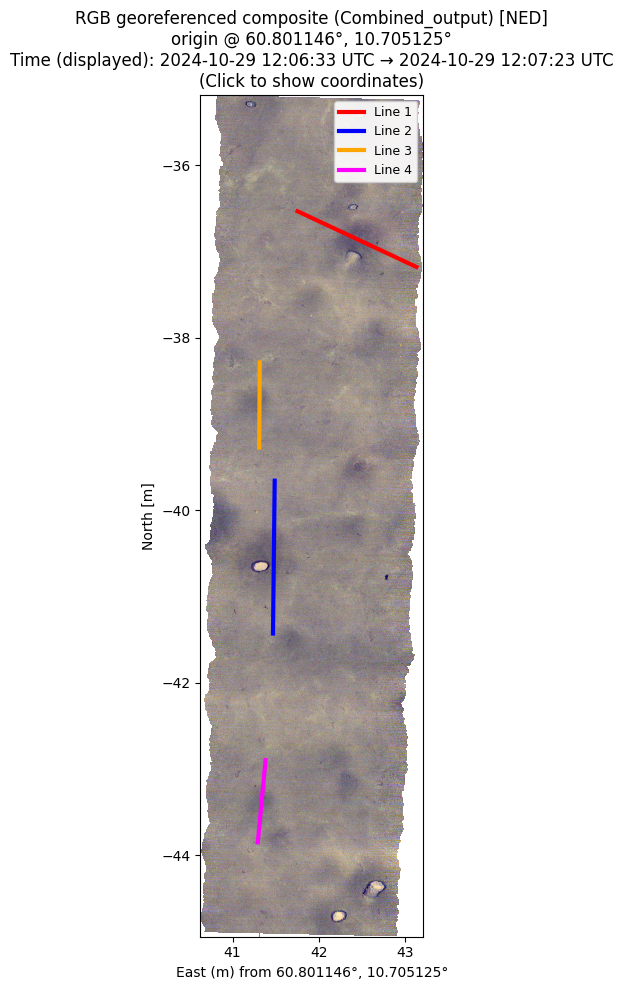

In [ ]:
# # Define analysis lines - ADJUSTED for track range (576-1566)
# # Place lines within visible data range
# line1 = [(410, 710), (940, 770)]
# line2 = [(340, 1030), (340, 1210)]
# line3 = [(250, 890), (250, 990)]
# line4 = [(300, 1358), (300, 1458)]

# lines = [line1, line2, line3, line4]
# colors = ["red", "blue", "orange", "magenta"]
# labels = ["Line 1", "Line 2", "Line 3", "Line 4"]

# # Plot RGB georef - EXACT wavelengths: 677nm (R), 610nm (G), 490nm (B)
# # plot_georef will find the CLOSEST available wavelength to these targets
# cube.plot_georef(
#     perimeter_line=lines,
#     line_colors=colors,
#     line_width=3,
#     line_labels=labels,
#     use_corrected=True,
#     coordinate_system="NED",
#     track_start=config.UHI_TRACK_RANGE[0],
#     track_end=config.UHI_TRACK_RANGE[1],
#     figsize=(30, 10),
#     apply_alignment_shift=True,
# )

In [7]:
## Intensity Profiles Along Lines

# Raw intensity profiles along lines
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


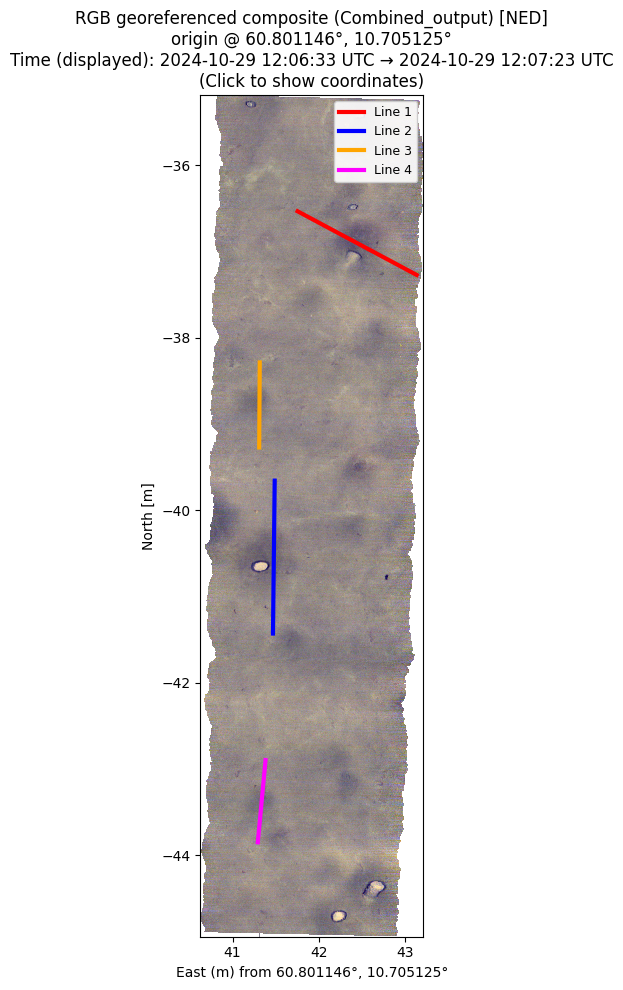

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


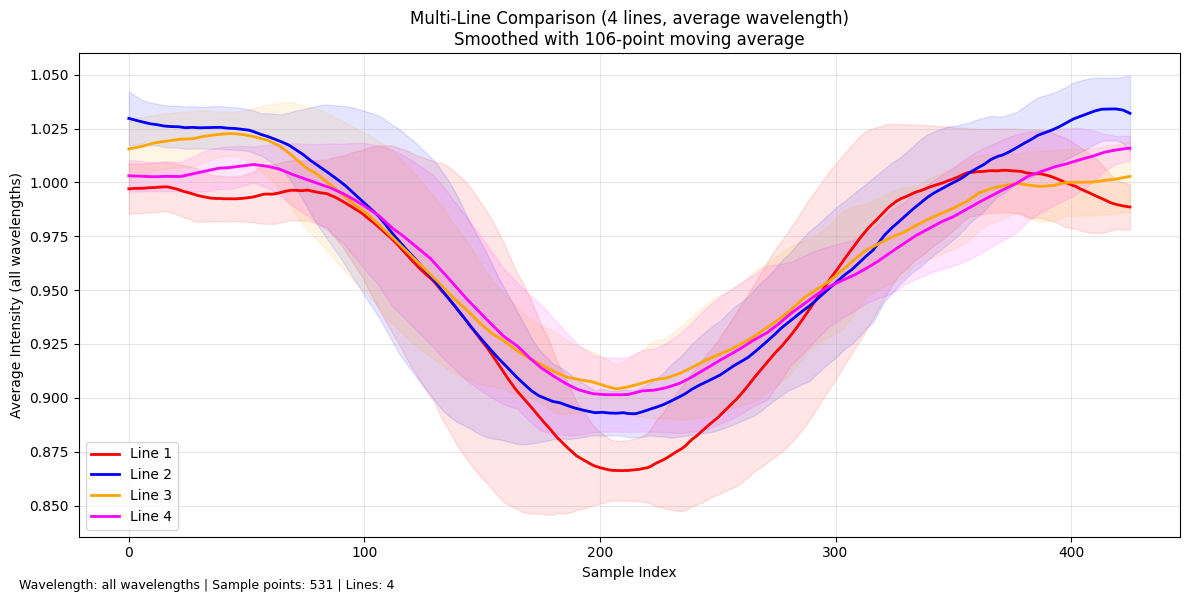

{'wavelength': 'all wavelengths',
 'wavelength_method': 'average',
 'smoothing_window': 106,
 'number_of_lines': 4,
 'sample_points': 531,
 'normalized': False,
 'normalization_method': None,
 'lines': [{'line_index': 1,
   'start_point': (410, 710),
   'end_point': (940, 780),
   'sample_indices': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
           13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
           26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
           39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
           52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
           65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
           78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
           91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
          104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
          117, 118, 119, 120

In [8]:
# Define analysis lines - ADJUSTED for track range (576-1566)
# Place lines within visible data range
line1 = [(410, 710), (940, 780)]
line2 = [(340, 1030), (340, 1210)]
line3 = [(250, 890), (250, 990)]
line4 = [(300, 1358), (300, 1458)]

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]

# Plot RGB georef - EXACT wavelengths: 677nm (R), 610nm (G), 490nm (B)
# plot_georef will find the CLOSEST available wavelength to these targets
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(30, 10),
    apply_alignment_shift=True,
)

# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
)

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


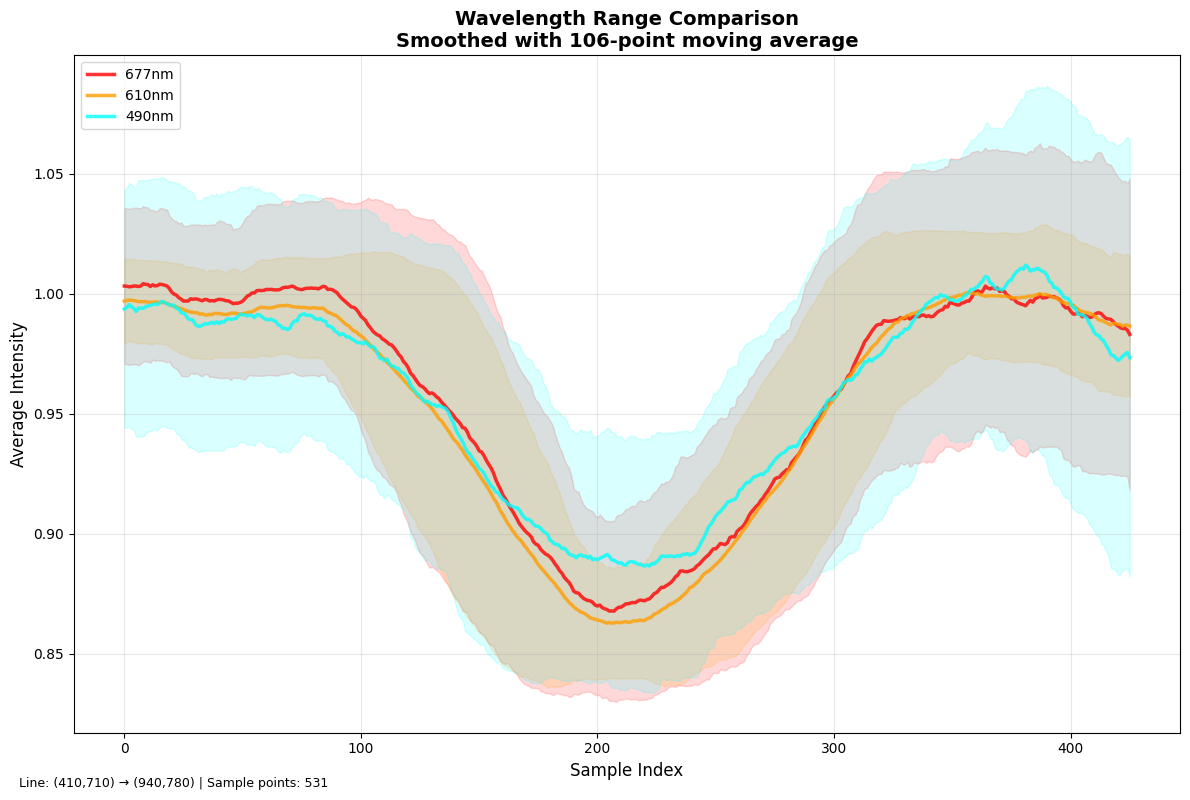

In [9]:
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[0],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
)

## Test New Features: Gaussian Smoothing & L2 Normalization

**⚠️ IMPORTANT: Restart kernel and re-run cells 1-6 before running tests below!**

Testing the new parameters:
- `smoothing_method="gaussian"` with `gaussian_sigma`
- `normalization_method="l2"` for L2 normalization

New features added to both `plot_line_intensity_profile` and `plot_wavelength_comparison`!

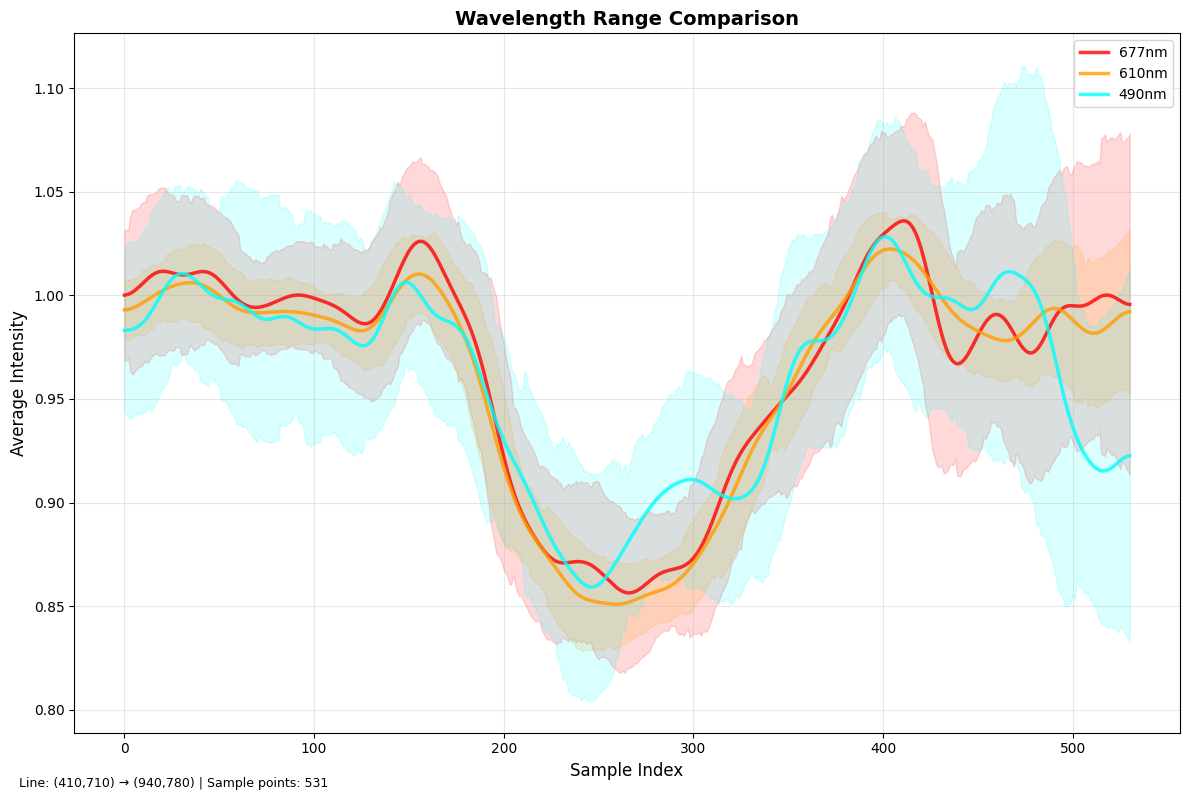


✅ Test 1 complete: Gaussian smoothing with sigma=2.0


In [16]:
# Test 1: Gaussian smoothing with different sigma values
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",  # NEW: Gaussian smoothing
    gaussian_sigma=10.0,  # NEW: Sigma parameter
    use_corrected=True,
)
print("\n✅ Test 1 complete: Gaussian smoothing with sigma=2.0")

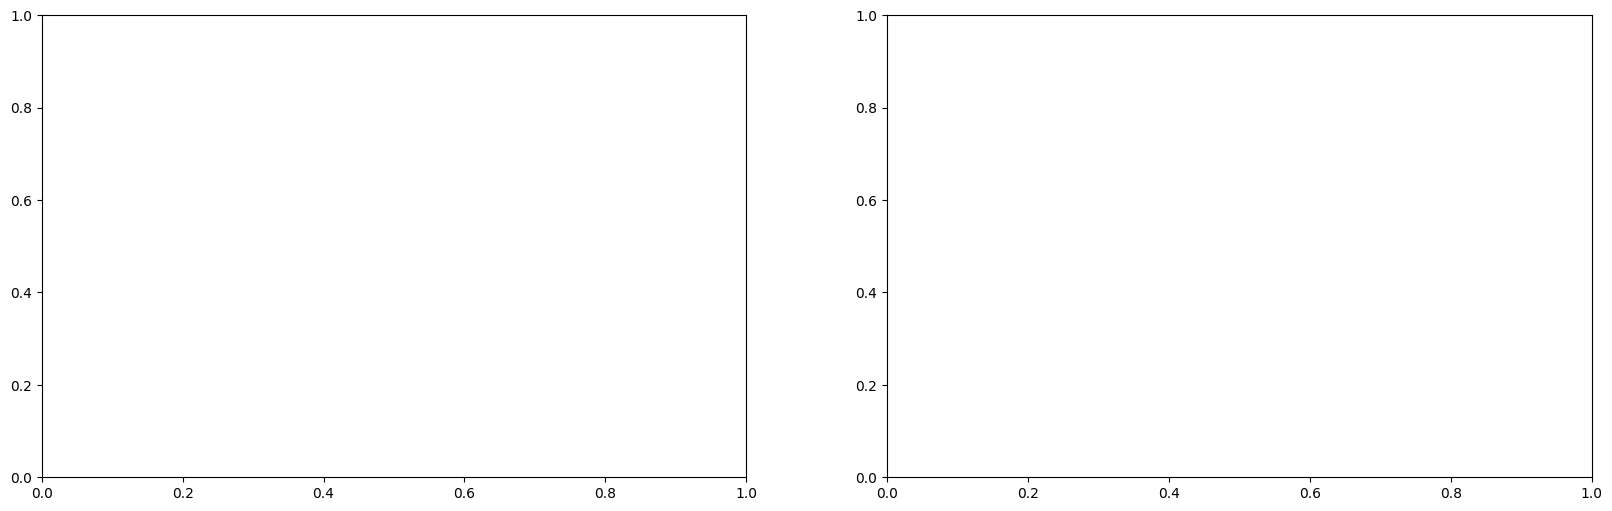

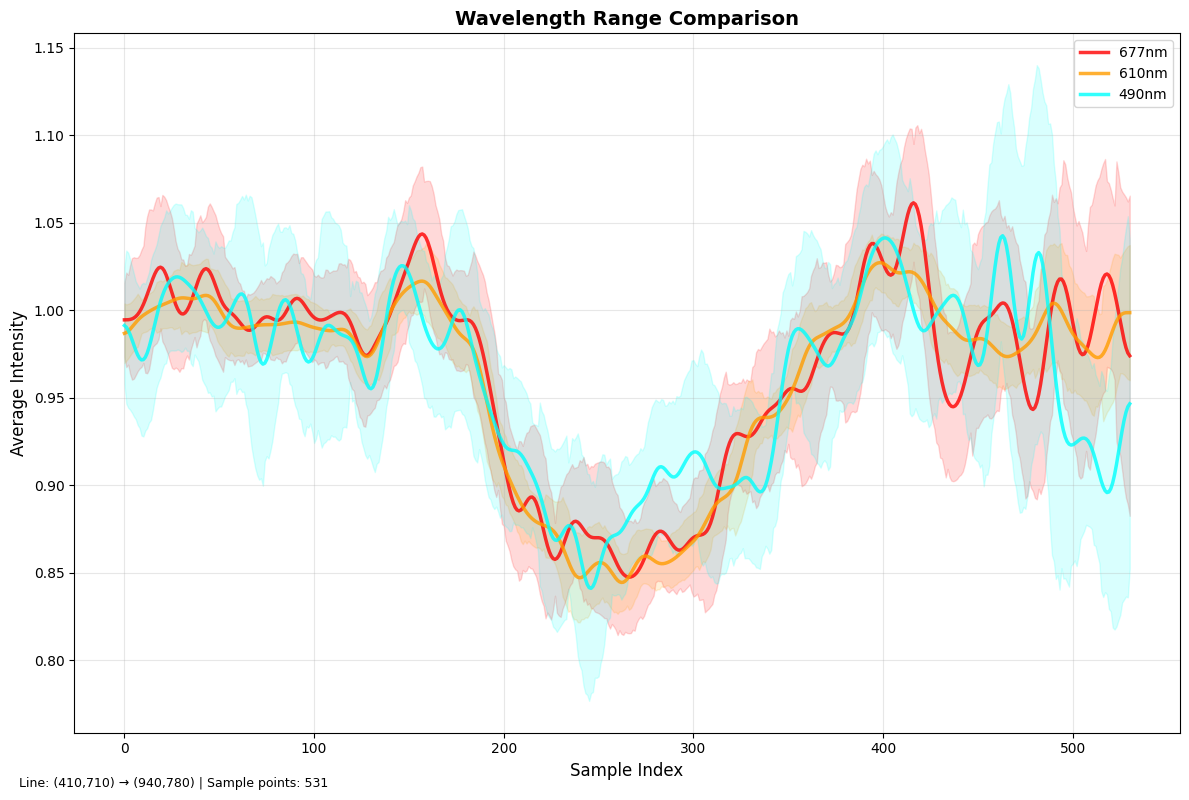

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


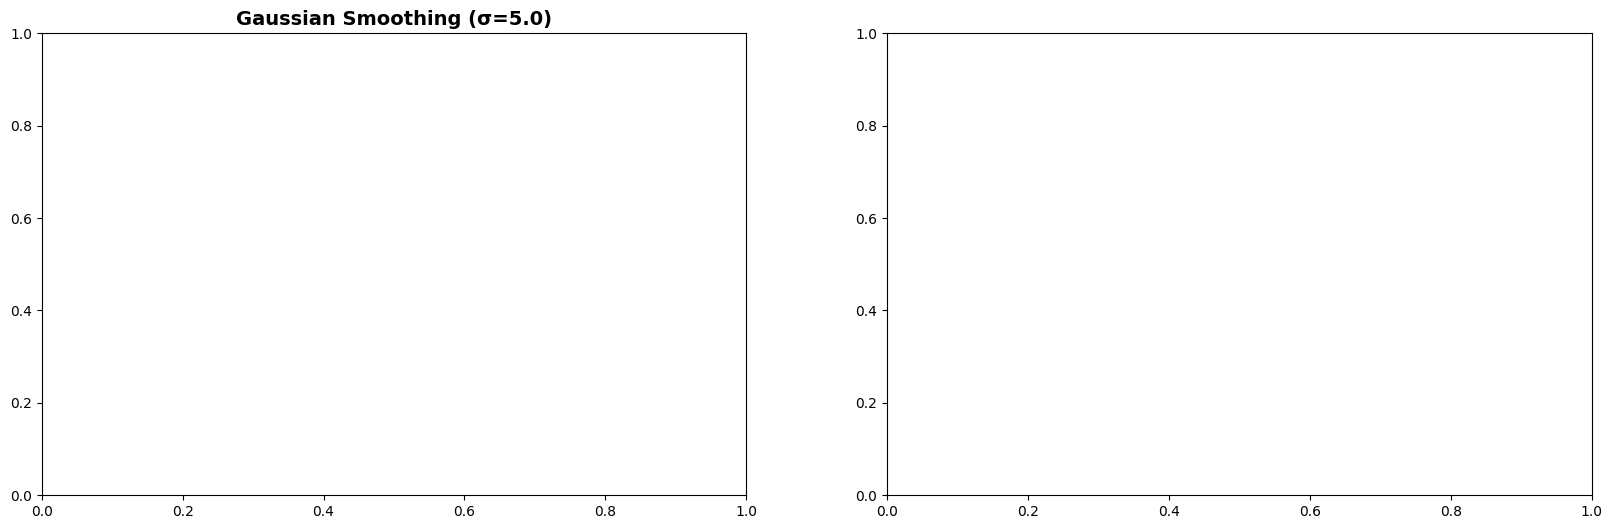

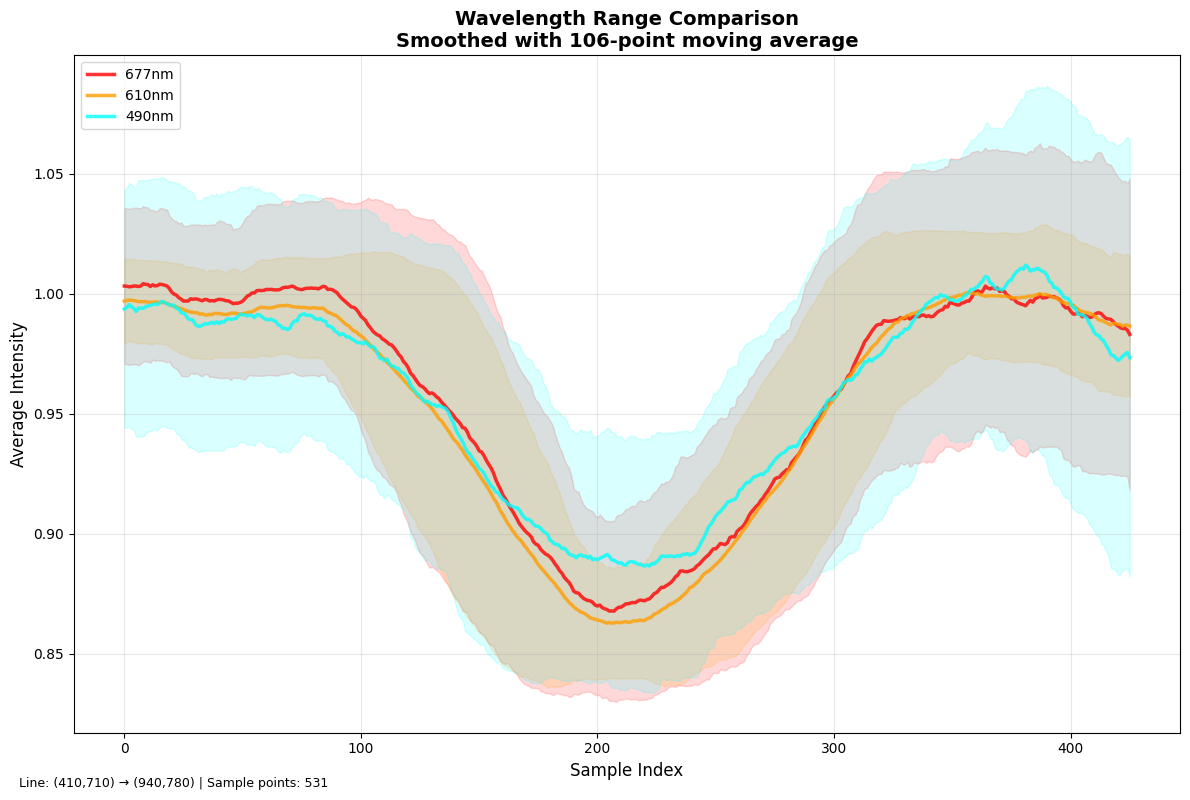

<Figure size 640x480 with 0 Axes>


✅ Test 2 complete: Gaussian vs Moving Average comparison


In [11]:
# Test 2: Compare Gaussian (sigma=5.0) vs Moving Average
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left: Gaussian smoothing
plt.sca(ax1)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=5.0,
    use_corrected=True,
)
ax1.set_title("Gaussian Smoothing (σ=5.0)", fontsize=14, fontweight="bold")

# Right: Moving average
plt.sca(ax2)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="moving_average",
    moving_average_percent=20,
    use_corrected=True,
)
ax2.set_title("Moving Average (20%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n✅ Test 2 complete: Gaussian vs Moving Average comparison")

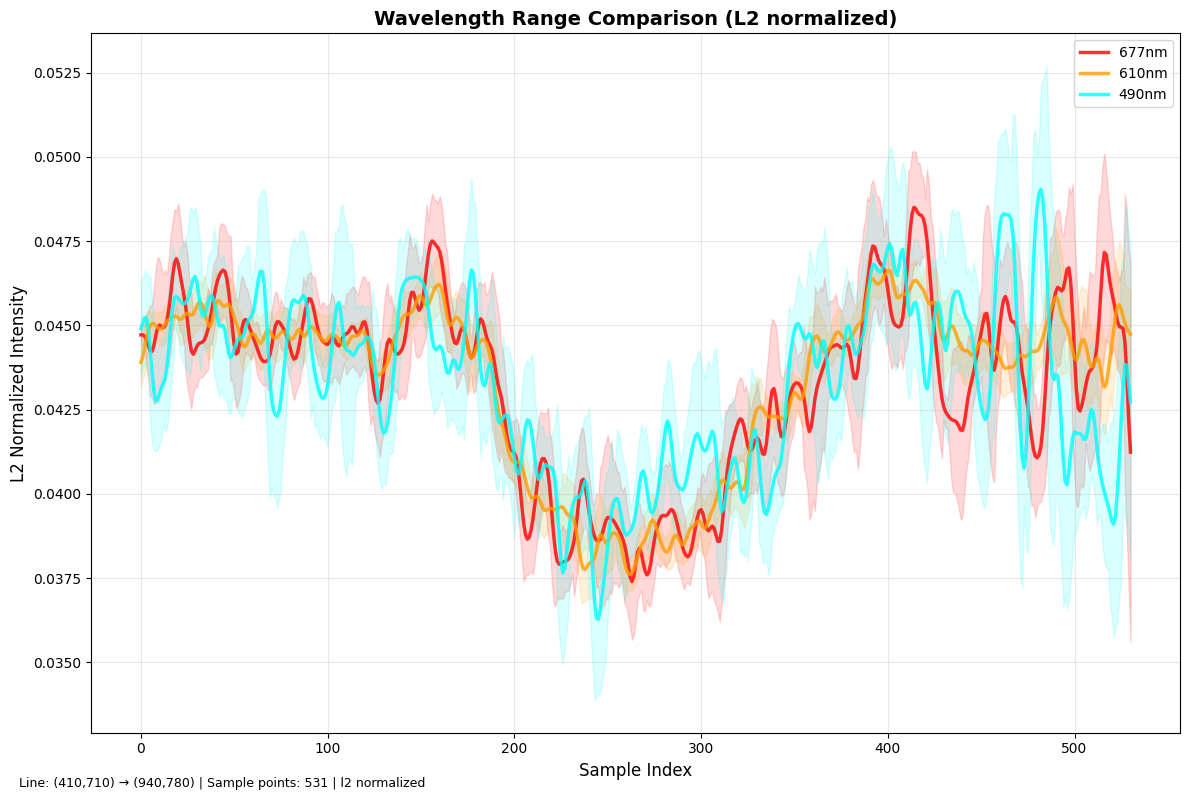


✅ Test 3 complete: L2 normalization
⚠️  Note: L2 normalization makes the intensity vector have Euclidean norm = 1


In [12]:
# Test 3: L2 Normalization
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=2.0,
    normalize_intensities=True,
    normalization_method="l2",  # NEW: L2 normalization (unit vector)
    use_corrected=True,
)
print("\n✅ Test 3 complete: L2 normalization")
print("⚠️  Note: L2 normalization makes the intensity vector have Euclidean norm = 1")

In [13]:
# # Test 4: Compare all normalization methods
# fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# normalization_methods = [
#     ("minmax", "MinMax [0-1]"),
#     ("zscore", "Z-Score"),
#     ("mean", "Mean-Relative"),
#     ("l2", "L2 (Unit Vector)"),
# ]

# for idx, (method, title) in enumerate(normalization_methods):
#     ax = axes[idx // 2, idx % 2]
#     plt.sca(ax)

#     cube.plot_wavelength_comparison(
#         line=lines[0],
#         wavelength_ranges=[677, 610, 490],
#         smoothing_method="gaussian",
#         gaussian_sigma=2.0,
#         normalize_intensities=True,
#         normalization_method=method,
#         use_corrected=True,
#     )
#     ax.set_title(f"{title} Normalization", fontsize=14, fontweight="bold")

# plt.tight_layout()
# plt.show()
# print("\n✅ Test 4 complete: All normalization methods compared")

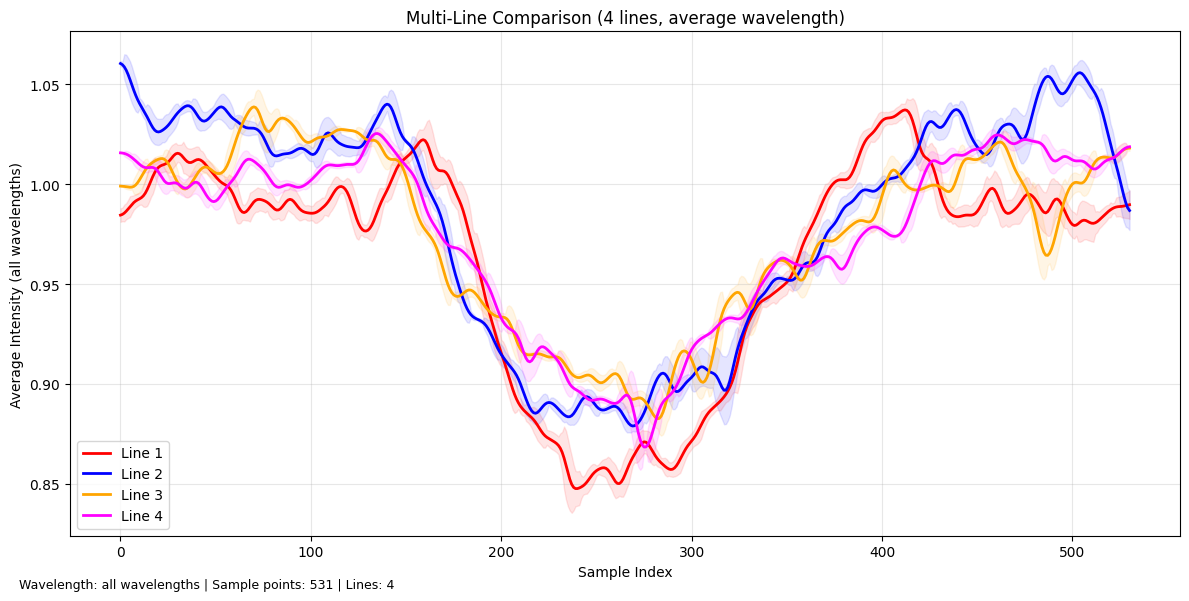


✅ Test 5 complete: Line intensity profiles with Gaussian smoothing


In [14]:
# Test 5: Line intensity profiles with Gaussian smoothing
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    wavelength_range="all",
    smoothing_method="gaussian",  # NEW: Use Gaussian instead of moving average
    gaussian_sigma=3.0,  # NEW: Sigma parameter
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
)
print("\n✅ Test 5 complete: Line intensity profiles with Gaussian smoothing")